In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt
from lightgbm import LGBMRegressor, log_evaluation
from sklearn.model_selection import train_test_split, KFold, cross_validate, RandomizedSearchCV
from sklearn.pipeline import Pipeline
from sklearn.metrics import r2_score, mean_absolute_error, root_mean_squared_error

from features.FeatureNameCleaner import FeatureNameCleaner
from features.preprocess import build_preprocessor
from features.feature_engineering import build_features, save_train_reference

from config.setting import MODEL_DIR, NUM_FEATURES
from utils.helper import get_data_path, get_project_root
import seaborn as sns

In [33]:
df = pd.read_csv(get_data_path("final_data.csv"))
print(f"Before cleaning: {len(df)} rows")

df = df.drop_duplicates()
df = df[(df["floors"] <= 15) | (df["floors"].isna())]

print(f"After cleaning: {len(df)} rows")

Before cleaning: 20356 rows
After cleaning: 20336 rows


In [40]:
df = df[(df.price > df.price.quantile(0.01)) &
        (df.price < df.price.quantile(0.99))]
train_df, test_df = train_test_split(df, test_size=0.2, random_state=42)
save_train_reference(train_df)

train_df = build_features(train_df, mode="train")
test_df = build_features(test_df, mode="predict")

X_train = train_df.drop("price", axis=1)
y_train = np.log1p(train_df["price"] * 1000 / train_df["area"])

X_test = test_df.drop("price", axis=1)
y_test = np.log1p(test_df["price"] * 1000 / test_df["area"])
print(f"\nTrain size: {len(X_train)}, Test size: {len(X_test)}")
print(f"Features: {X_train.shape[1]} columns")


Train size: 15923, Test size: 3981
Features: 30 columns


In [27]:
df = df[(df.price > df.price.quantile(0.01)) &
        (df.price < df.price.quantile(0.99))]
train_df, test_df = train_test_split(df, test_size=0.2, random_state=42)
save_train_reference(train_df)

train_df = build_features(train_df, mode="train")
test_df = build_features(test_df, mode="predict")

X_train = train_df.drop("price", axis=1)
y_train = train_df["price"]

X_test = test_df.drop("price", axis=1)
y_test = test_df["price"]
print(f"\nTrain size: {len(X_train)}, Test size: {len(X_test)}")
print(f"Features: {X_train.shape[1]} columns")


Train size: 15923, Test size: 3981
Features: 30 columns


In [41]:
model = LGBMRegressor(
    learning_rate=0.05,
    n_estimators=1500,
    num_leaves=31,
    max_depth=8,
    min_child_samples=30,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=0.5,
    random_state=42,
    verbose=-1,
)

pipe = Pipeline([
    ("prep", build_preprocessor()),
    ("clean_names", FeatureNameCleaner()),
    ("model", model)
])

In [44]:
from lightgbm import early_stopping

X_tr, X_val, y_tr, y_val = train_test_split(
    X_train, y_train, test_size=0.1, random_state=42
)

preprocessor = pipe.named_steps["prep"]
cleaner = pipe.named_steps["clean_names"]
model = pipe.named_steps["model"]

X_tr_processed = cleaner.fit_transform(preprocessor.fit_transform(X_tr))
X_val_processed = cleaner.transform(preprocessor.transform(X_val))

model.fit(
    X_tr_processed, y_tr,
    eval_set=[(X_val_processed, y_val)],
    eval_metric="rmse",
    callbacks=[
        early_stopping(stopping_rounds=50),
        log_evaluation(period=100)
    ]
)

print(f"\nBest iteration: {model.best_iteration_}")
print(f"Best score (val): {model.best_score_}")

Training until validation scores don't improve for 50 rounds
[100]	valid_0's rmse: 0.194555	valid_0's l2: 0.0378515
[200]	valid_0's rmse: 0.188456	valid_0's l2: 0.0355158
[300]	valid_0's rmse: 0.186762	valid_0's l2: 0.0348799
[400]	valid_0's rmse: 0.185394	valid_0's l2: 0.0343709
[500]	valid_0's rmse: 0.184988	valid_0's l2: 0.0342204
[600]	valid_0's rmse: 0.184625	valid_0's l2: 0.0340862
[700]	valid_0's rmse: 0.184283	valid_0's l2: 0.0339601
Did not meet early stopping. Best iteration is:
[770]	valid_0's rmse: 0.183938	valid_0's l2: 0.0338331

Best iteration: 770
Best score (val): defaultdict(<class 'collections.OrderedDict'>, {'valid_0': OrderedDict([('rmse', np.float64(0.1839377100204488)), ('l2', np.float64(0.03383308116756672))])})


In [45]:
model = LGBMRegressor(
    learning_rate=0.05,
    n_estimators=770,
    num_leaves=31,
    max_depth=8,
    min_child_samples=30,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=0.5,
    random_state=42,
    verbose=-1,
)

pipe = Pipeline([
    ("prep", build_preprocessor()),
    ("clean_names", FeatureNameCleaner()),
    ("model", model)
])
pipe.fit(X_train, y_train)

Pipeline(steps=[('prep',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median'))]),
                                                  ['year', 'log_area',
                                                   'bedrooms', 'bathrooms',
                                                   'floors', 'lat', 'lng',
                                                   'dist_center',
                                                   'log_dist_center',
                                                   'zone_price_mean',
                                                   'knn_price_mean',
                                                   'knn_price_median',
                                                   'knn_price_std',
                                                   'neighbor_density',
                                                   'area_zone_price',
                                                   'area_x_bedrooms',
                                                   'flo...
                                                                   OrdinalEncoder(handle_unknown='use_encoded_value',
                                                                                  unknown_value=-1))]),
                                                  ['legal_status',
                                                   'furniture_state',
                                                   'property_type',
                                                   'property_feature'])])),
                ('clean_names', FeatureNameCleaner()),
                ('model',
                 LGBMRegressor(colsample_bytree=0.8, learning_rate=0.05,
                               max_depth=8, min_child_samples=30,
                               n_estimators=770, random_state=42, reg_alpha=0.1,
                               reg_lambda=0.5, subsample=0.8, verbose=-1))])

In [46]:
kfold = KFold(n_splits=5, shuffle=True, random_state=42)

scores = cross_validate(
    pipe, X_train, y_train,
    cv=kfold,
    scoring={
        "mae": "neg_mean_absolute_error",
        "rmse": "neg_root_mean_squared_error",
        "r2": "r2"
    }
)

print("\n=== CROSS-VALIDATION RESULTS ===")
print(f"CV MAE:  {-scores['test_mae'].mean():.5f}")
print(f"CV RMSE: {-scores['test_rmse'].mean():.5f}")
print(f"CV R2:   {scores['test_r2'].mean():.5f}")


=== CROSS-VALIDATION RESULTS ===
CV MAE:  0.13639
CV RMSE: 0.18542
CV R2:   0.80784



=== TRAIN PERFORMANCE ===
RMSE: 0.13113
MAE:  0.09786
R2:   0.90399

=== TEST PERFORMANCE ===
RMSE: 0.18494
MAE:  0.13851
R2:   0.80913

MAE (price per m2): 15.37 triệu/m²
MAE (total price): 0.88 tỷ
MAPE: 14.4%
MAPE: 14.4%


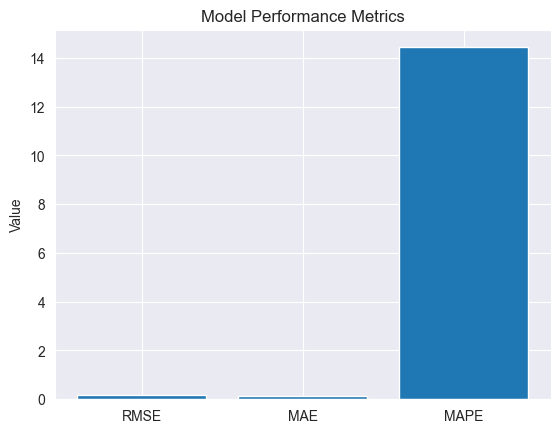

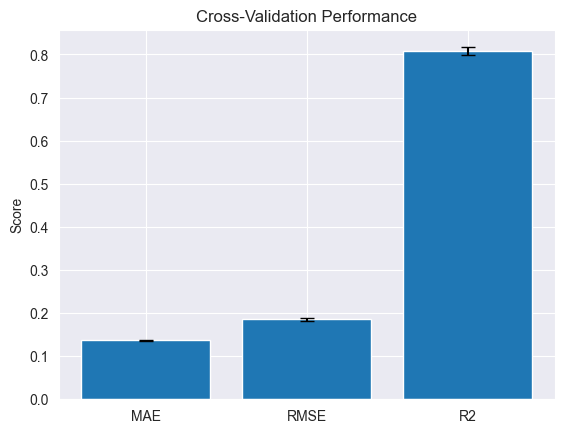

C:\Users\ASUS\AppData\Local\Temp\ipykernel_1628\438974023.py:61: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([


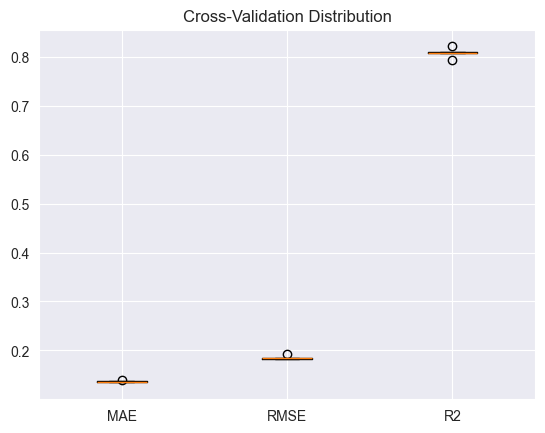

In [47]:
train_pred_log = pipe.predict(X_train)
test_pred_log = pipe.predict(X_test)

print("\n=== TRAIN PERFORMANCE ===")
print(f"RMSE: {root_mean_squared_error(y_train, train_pred_log):.5f}")
print(f"MAE:  {mean_absolute_error(y_train, train_pred_log):.5f}")
print(f"R2:   {r2_score(y_train, train_pred_log):.5f}")

print("\n=== TEST PERFORMANCE ===")
print(f"RMSE: {root_mean_squared_error(y_test, test_pred_log):.5f}")
print(f"MAE:  {mean_absolute_error(y_test, test_pred_log):.5f}")
print(f"R2:   {r2_score(y_test, test_pred_log):.5f}")

y_pred_price_m2 = np.expm1(test_pred_log)
y_test_price_m2 = np.expm1(y_test)
mae_price_m2 = mean_absolute_error(y_test_price_m2, y_pred_price_m2)
print(f"\nMAE (price per m2): {mae_price_m2:.2f} triệu/m²")

y_pred_total = y_pred_price_m2 * test_df["area"].values / 1000
y_test_total = test_df["price"].values
mae_total = mean_absolute_error(y_test_total, y_pred_total)
print(f"MAE (total price): {mae_total:.2f} tỷ")

mape = np.mean(np.abs((y_test_total - y_pred_total) / (y_test_total + 1e-8))) * 100
print(f"MAPE: {mape:.1f}%")
print(f"MAPE: {mape:.1f}%")

metrics = ["RMSE", "MAE", "MAPE"]
values = [
    root_mean_squared_error(y_test, test_pred_log),
    mean_absolute_error(y_test, test_pred_log),
    mape
]

plt.figure()
plt.bar(metrics, values)
plt.title("Model Performance Metrics")
plt.ylabel("Value")
plt.show()

import matplotlib.pyplot as plt

cv_metrics = ["MAE", "RMSE", "R2"]
cv_means = [
    -scores['test_mae'].mean(),
    -scores['test_rmse'].mean(),
    scores['test_r2'].mean()
]
cv_stds = [
    scores['test_mae'].std(),
    scores['test_rmse'].std(),
    scores['test_r2'].std()
]

plt.figure()
plt.bar(cv_metrics, cv_means, yerr=cv_stds, capsize=5)
plt.title("Cross-Validation Performance")
plt.ylabel("Score")
plt.show()
plt.figure()
plt.boxplot([
    -scores['test_mae'],
    -scores['test_rmse'],
    scores['test_r2']
], labels=["MAE", "RMSE", "R2"])

plt.title("Cross-Validation Distribution")
plt.show()

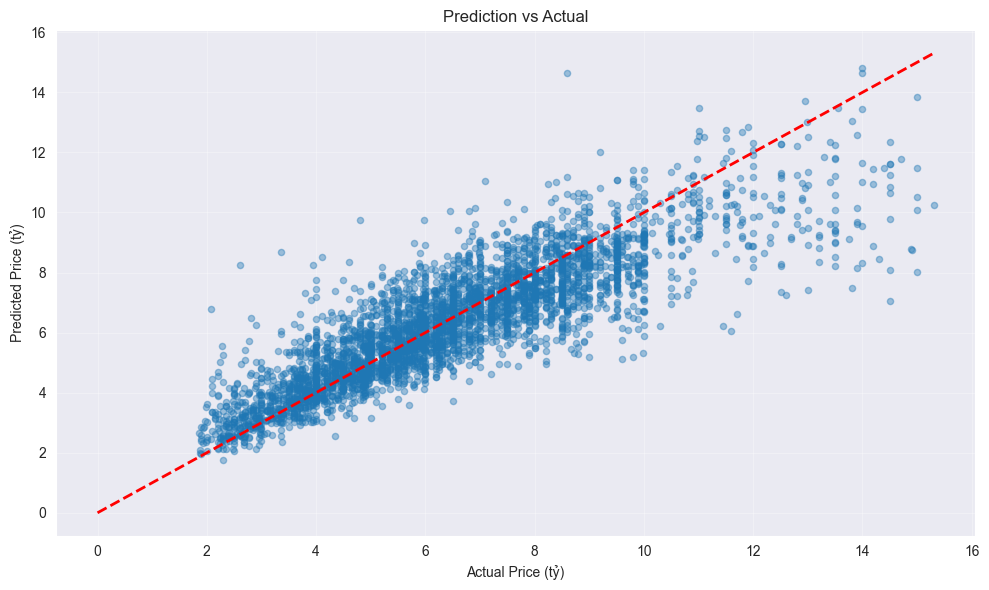

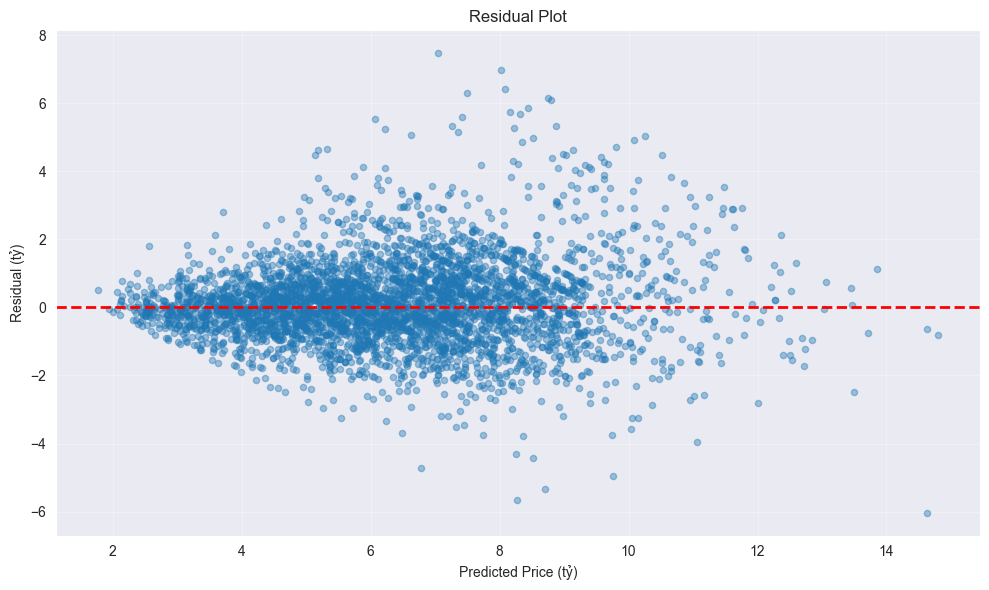

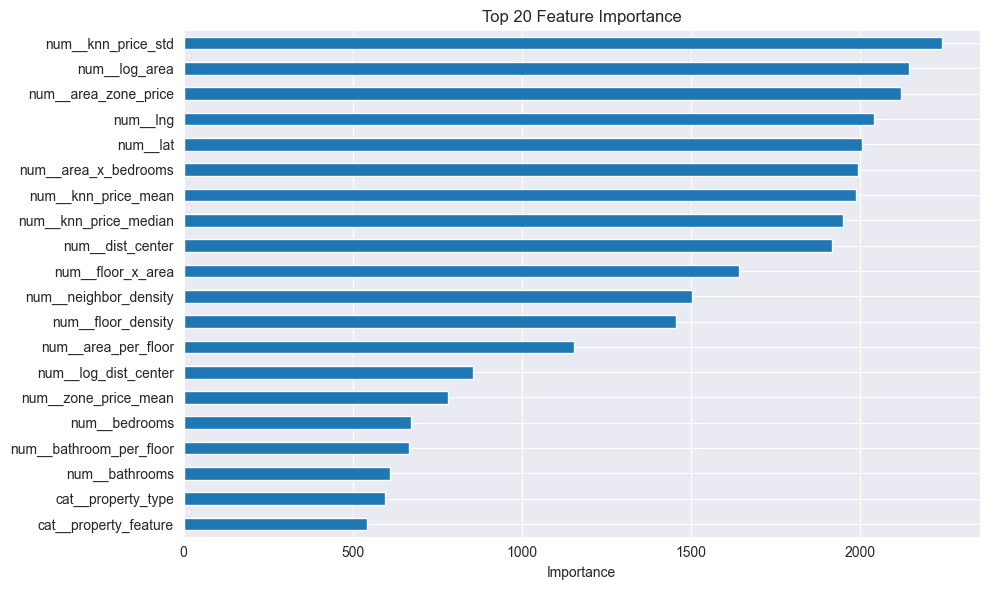

<Figure size 640x480 with 0 Axes>

In [29]:
y_pred_price_m2 = np.expm1(test_pred_log)
y_pred_total = y_pred_price_m2 * test_df["area"].values / 1000
y_test_total = test_df["price"].values

plt.figure(figsize=(10, 6))

plt.scatter(y_test_total, y_pred_total, alpha=0.4, s=20)

max_val = max(y_test_total.max(), y_pred_total.max())
plt.plot([0, max_val], [0, max_val], "r--", linewidth=2)

plt.xlabel("Actual Price (tỷ)")
plt.ylabel("Predicted Price (tỷ)")
plt.title("Prediction vs Actual")

plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("prediction_vs_actual.png", dpi=300, bbox_inches="tight")
plt.show()

plt.figure(figsize=(10, 6))

residuals = y_test_total - y_pred_total
plt.scatter(y_pred_total, residuals, alpha=0.4, s=20)

plt.axhline(y=0, color="r", linestyle="--", linewidth=2)

plt.xlabel("Predicted Price (tỷ)")
plt.ylabel("Residual (tỷ)")
plt.title("Residual Plot")

plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("residual_plot.png", dpi=300, bbox_inches="tight")
plt.show()


preprocessor = pipe.named_steps["prep"]
model = pipe.named_steps["model"]
feature_names = preprocessor.get_feature_names_out()
importances = model.feature_importances_

feat_imp = pd.Series(importances, index=feature_names)
feat_imp = feat_imp.sort_values(ascending=False)
top_features = feat_imp.head(20)
plt.figure(figsize=(10, 6))

top_features.sort_values().plot(kind="barh")

plt.title("Top 20 Feature Importance")
plt.xlabel("Importance")

plt.tight_layout()
plt.show()

plt.savefig("feature_importance.png", dpi=300, bbox_inches="tight")

In [12]:
model_path = Path(get_project_root()) / MODEL_DIR / "lgbm.pkl"
joblib.dump(pipe, model_path)
print(f"\nModel saved to: {model_path}")


Model saved to: D:\code\DA\TLand-Backend\rag-chatbot-service\models\lgbm.pkl


In [48]:
from sklearn.model_selection import RandomizedSearchCV

param_dist = {
    "model__learning_rate": [0.01, 0.03, 0.05, 0.1],
    "model__n_estimators": [770],
    "model__num_leaves": [15, 31, 63],
    "model__max_depth": [-1, 6, 8, 10],
    "model__min_child_samples": [10, 20, 30, 50],
    "model__subsample": [0.6, 0.8, 1.0],
    "model__colsample_bytree": [0.6, 0.8, 1.0],
    "model__reg_alpha": [0, 0.1, 0.5],
    "model__reg_lambda": [0, 0.5, 1]
}

random_search = RandomizedSearchCV(
    estimator=pipe,
    param_distributions=param_dist,
    n_iter=30,  # số lần thử
    scoring="neg_root_mean_squared_error",
    cv=5,  # cross validation
    verbose=2,
    random_state=42,
    n_jobs=-1
)

random_search.fit(X_train, y_train)

print("Best params:", random_search.best_params_)
print("Best score:", -random_search.best_score_)

Fitting 5 folds for each of 30 candidates, totalling 150 fits
Best params: {'model__subsample': 0.8, 'model__reg_lambda': 0, 'model__reg_alpha': 0.1, 'model__num_leaves': 63, 'model__n_estimators': 770, 'model__min_child_samples': 20, 'model__max_depth': 8, 'model__learning_rate': 0.05, 'model__colsample_bytree': 0.6}
Best score: 0.18388433936125187
